In [2]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 35.2 MB/s eta 0:00:00


In [23]:
import pandas as pd
import numpy as np
import hdbscan
import seaborn as sns
import matplotlib.pyplot as plt
import faiss
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

In [66]:
UMAP_clu=pd.read_csv('UMAP_clu.csv')
features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()

In [5]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=15).fit(features)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<ipython-input-6-76121cbd163b>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clusterer.outlier_scores_[np.isfinite(clusterer.outlier_scores_)], rug=True)


<Axes: ylabel='Density'>

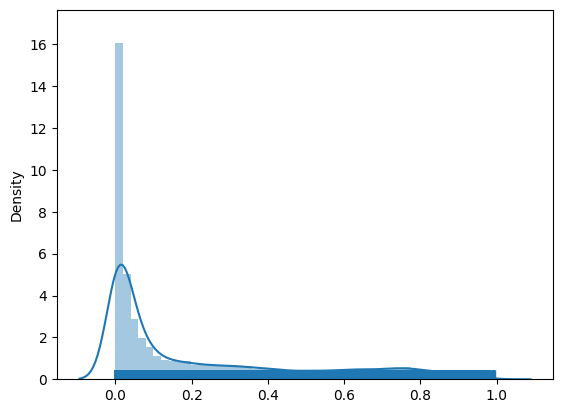

In [6]:
# Plot outlier score distribution
sns.distplot(clusterer.outlier_scores_[np.isfinite(clusterer.outlier_scores_)], rug=True)

In [7]:
# Assuming clusterer.outlier_scores_ and features are already defined
threshold = pd.Series(clusterer.outlier_scores_).quantile(0.9)
outliers = np.where(clusterer.outlier_scores_ > threshold)[0]


In [67]:
UMAP_clu['outlier'] = np.where(UMAP_clu.index.isin(outliers), 1, 0)

In [9]:
UMAP_clu['outlier'].value_counts()

,count
outlier,
0,44850
1,4984


In [10]:
kmeans_input = UMAP_clu[UMAP_clu['outlier'] == 0]

# Using faiss library to use cosine distance

# Define the range for the number of clusters to test
cluster_ranges = range(2, 31)

features = kmeans_input.drop(columns=['user_uid','cluster','outlier'])

# Normalize features to unit length (cosine distance equivalent)
features_normalized = normalize(features, norm='l2', axis=1)

results = []
# Loop over the number of clusters for KMeans
for n_clusters in cluster_ranges:
        # Initialize Faiss KMeans with cosine distance
        d = features_normalized.shape[1]
        kmeans = faiss.Kmeans(d=d, k=n_clusters, niter=20, spherical=True, seed=42)

        # Train Faiss KMeans
        kmeans.train(features_normalized)
        D, cluster_labels = kmeans.index.search(features_normalized, 1)  # Cluster assignments

        # Calculate the silhouette score
        silhouette_avg = silhouette_score(features_normalized, cluster_labels.ravel())

        # Store the result
        results.append((n_clusters, silhouette_avg))

# Convert results to a DataFrame for analysis
results_df = pd.DataFrame(results, columns=['n_clusters', 'silhouette_score'])
results_df

,n_clusters,silhouette_score
0,2,0.361710
1,3,0.308281
2,4,0.267588
3,5,0.273788
4,6,0.346188
5,7,0.349997
6,8,0.277995
7,9,0.300767
8,10,0.305323
9,11,0.321549


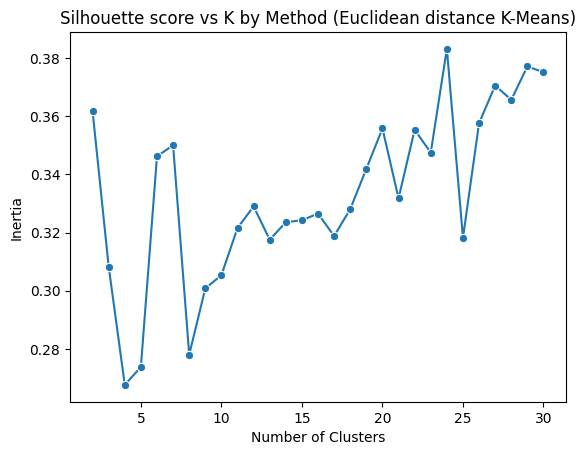

In [13]:
# Create the line plot
sns.lineplot(results_df, x="n_clusters", y="silhouette_score", marker="o")

# Add labels and title
plt.title("Silhouette score vs K by Method (Euclidean distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

# Display the plot
plt.show()

n_clusters = 24, Avg silhouette_score: 0.3831258786243347


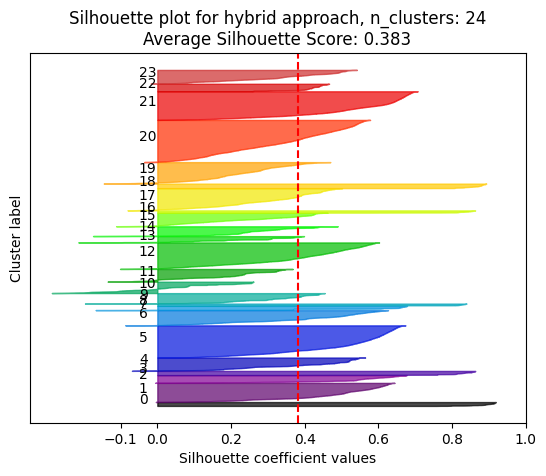

In [26]:
features = kmeans_input.drop(columns=['user_uid','cluster','outlier'])

# Normalize features to unit length (cosine distance equivalent)
features_normalized = normalize(features, norm='l2', axis=1)

n_clusters = 24
d = features_normalized.shape[1]

# Initialize FAISS KMeans
clusterer = faiss.Kmeans(d=d, k=n_clusters, niter=20, spherical=True, seed=42)

# Train the clusterer
clusterer.train(features_normalized)

# Assign cluster labels
_, cluster_labels = clusterer.index.search(features_normalized, 1)
cluster_labels = cluster_labels.flatten()  # Convert to 1D array

# Compute silhouette scores
silhouette_avg = silhouette_score(features_normalized, cluster_labels)
print(f"n_clusters = {n_clusters}, Avg silhouette_score: {silhouette_avg}")

sample_silhouette_values = silhouette_samples(features_normalized, cluster_labels)

y_lower = 10
for i in range(n_clusters):
        # Sort and aggregate silhouette scores for cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label clusters
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

plt.title(f"Silhouette plot for hybrid approach, n_clusters: {n_clusters}\nAverage Silhouette Score: {silhouette_avg:.3f}")
plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster label")
plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.yticks([])
plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.show()

In [59]:
kmeans_input

,UMAP_1,UMAP_2,UMAP_3,UMAP_4,UMAP_5,UMAP_6,UMAP_7,UMAP_8,UMAP_9,UMAP_10,user_uid,cluster,outlier,k_means_clusters
0,9.993732,4.840664,3.759140,1.681379,8.547821,4.459381,5.279981,3.486582,7.264886,5.783343,0014e5b67b7e4168b9ef114078de31ce,Psycho-reality,0,20
1,9.117845,2.022213,2.929033,-0.406795,6.905996,3.415126,4.417592,4.336042,5.715226,4.842009,c374440454964353b06a2ccf54f47fa0,Mafia fiction,0,9
2,10.187436,4.387349,3.500721,1.976976,8.428779,4.304406,4.980549,3.231488,7.446157,6.629414,0050aba065644cf2bcb3d074450c97fe,Psycho-reality,0,20
3,10.450864,4.822343,4.286945,1.198168,7.940255,4.274079,4.586243,3.342474,5.809216,6.114284,00789b082a7e4ddab241cfdae96a7f29,Info lover,0,23
4,10.366046,4.261064,3.845609,0.889594,7.933178,4.608691,4.928448,4.007844,4.500133,5.361030,00884f1a705344bcb3ed76f981c3ae47,Satira e costume,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49829,10.314897,4.303755,3.828694,0.985465,7.923391,4.687006,4.935307,4.165947,4.741426,5.339151,019eb82b710b41ab8911a045c77d4dae,Satira e costume,0,15
49830,10.689524,4.650914,3.719871,2.291425,8.008928,3.523648,5.307108,3.130776,6.377204,6.097464,000a5666449741cfaeb8348b691f053c,Tendenza Amici,0,23
49831,9.907635,3.303587,3.051730,1.026947,8.187387,4.829055,3.985647,2.802459,7.885709,7.430202,0199fbbc1f1f4b52806bbf76155eea72,TerraAmara only,0,12
49832,10.731705,2.351936,1.589038,8.335363,7.015727,3.519250,5.222106,3.117764,4.526671,4.623148,01d8655f83a44033a260b17b7c56402c,Tendenza Amici,0,0


In [70]:

hybrid_output=UMAP_clu
hybrid_output['k_means_clusters']=kmeans_input['k_means_clusters'].astype(int)
hybrid_output['hybrid_clusters']= np.where(hybrid_output['outlier']==1, -1, hybrid_output['k_means_clusters'])

,UMAP_1,UMAP_2,UMAP_3,UMAP_4,UMAP_5,UMAP_6,UMAP_7,UMAP_8,UMAP_9,UMAP_10,user_uid,cluster,outlier,k_means_clusters,hybrid_clusters
21,10.375305,3.759634,2.845867,1.335562,7.990243,5.690185,3.667672,3.631832,3.199098,4.671484,c472a9294ca847b08e7167583ad62e1b,Defilippismo lacrimevole,1,NaN,-1.0
32,9.849063,3.180771,3.748210,1.117525,7.259912,4.358124,4.447370,3.864183,4.459252,5.795070,c47951eaeda9497d99b46c7c8d1d3661,Defilippismo ludo-competitivo,1,NaN,-1.0
33,10.736690,1.257710,2.378440,-0.034081,5.436530,3.982961,3.116169,2.977914,4.469975,4.542818,0163ddf5ac0d4440ad19708f803ac7a6,New Amsterdam only,1,NaN,-1.0
50,8.591519,1.686991,3.543077,-1.048864,6.629374,3.126971,4.681395,5.182808,4.332662,4.186968,000ff00a3d31457eab9cc3a1d1dd9d0f,Film con leggerezza,1,NaN,-1.0
61,10.469453,5.174466,4.484442,1.188293,8.000998,4.293717,4.623360,3.406002,6.074711,6.054716,c2f14aadaf5d4a26a1a416643b06f834,Soappettari,1,NaN,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49727,9.744158,2.864277,2.150146,0.651440,7.997976,4.219525,4.816652,3.354110,7.269661,5.207728,00d8befc5bd743b0b5c5592a534a91fb,Solo fiction italiana,1,NaN,-1.0
49757,10.369663,4.263966,3.776577,0.960697,7.895969,4.758458,4.726508,4.011681,4.823897,5.420234,c2c50b876f0d493da2eb49089458b413,Polemicanti,1,NaN,-1.0
49758,10.088717,1.804474,2.672421,-0.150538,6.342263,3.524253,3.424513,3.405860,6.195823,5.359248,c4143caff87845879e2172cbc9145e13,Soappettari,1,NaN,-1.0
49782,9.335411,3.643335,3.460084,1.899605,8.126187,4.351138,5.757288,3.928281,6.857316,5.162825,00d65a7d073a4b2ea884ae4fd04ce19c,Tendenza Amici,1,NaN,-1.0


In [75]:
UMAP_euclidean=pd.read_csv('UMAP_euclidean.csv')

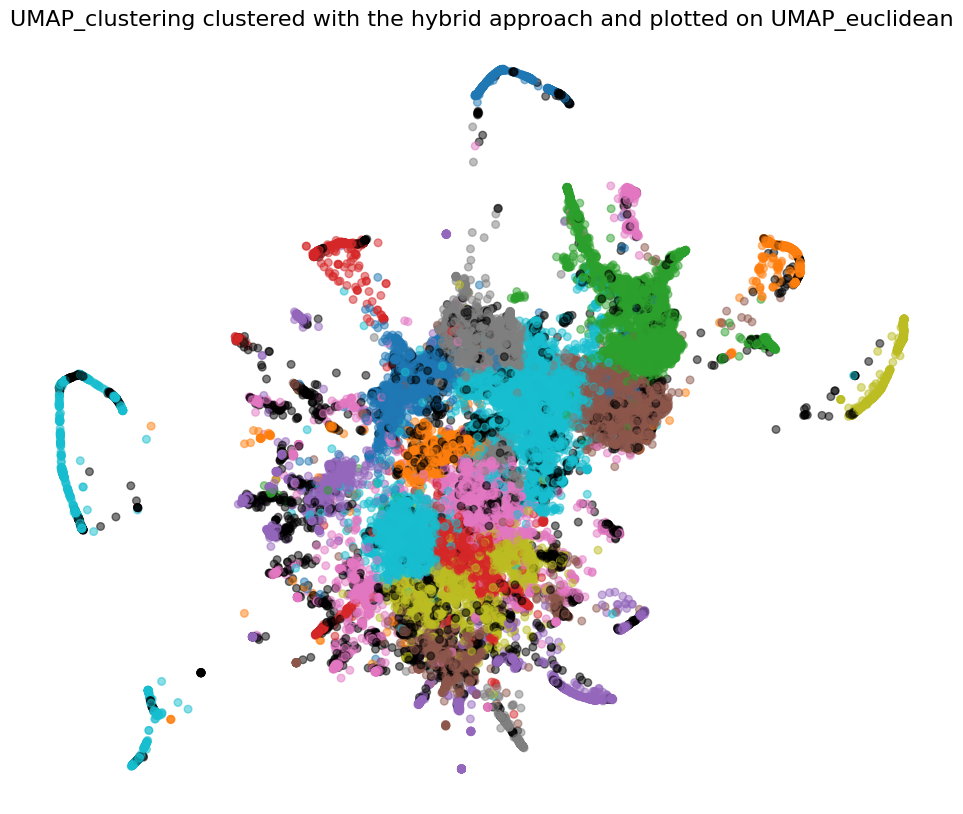

In [78]:

# Assuming hdbscan_labels and UMAP_euclidean are already defined

# Get unique labels and count clusters (excluding noise)
unique_labels = np.unique(hybrid_output['hybrid_clusters'])
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

# Create a colormap for valid clusters (excluding noise)
cluster_cmap = plt.get_cmap("tab10", num_clusters)  # Change colormap if needed

# Generate colors for clusters, mapping -1 to gray
color_dict = {label: cluster_cmap(i) for i, label in enumerate(unique_labels) if label != -1}
color_dict[-1] = "black"  # Explicitly assign gray to noise points

# Convert labels to corresponding colors (store as a list instead of NumPy array)
color = [color_dict[label] for label in hybrid_output['hybrid_clusters']]

# Extract UMAP coordinates
x, y = UMAP_euclidean['UMAP_1'], UMAP_euclidean['UMAP_2']

# Plot the embedding
plt.figure(figsize=(12, 10))

# Scatter plot with colors
plt.scatter(x, y, c=color, s=30, alpha=0.5)

# Set title and labels
plt.title("UMAP_clustering clustered with the hybrid approach and plotted on UMAP_euclidean", fontsize=16)
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)

# Hide axes for a cleaner look
plt.axis('off')

# Show the plot
plt.show()